# **Customer Churn Analysis for an Hungarian Telecom Company**
**Presented by:**


*   Mukhammad Azim
*   Móger Máté
*   Jose Ocoro

## **Introduction**

The following project is in collaboration with an Hungarian Telecom Company, which in its latest operating periods has noticed a growing churn rate among its customers since the arrival of new competitors to the Hungarian market.

The main objetive of this project is to run an exploratory analyisis from its customer database, understand the reason this churn rate is increasing and develop an ML model to predict potential churn of its customers, in order to prevent these customers from abandoning the company's services through retention campaigns driven by the company's sales and marketing team.

For that purpose, the Data analysis team will work with a dataset of customers provided by the company.



### **1. Loading required packages**


In [18]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Modeling prep
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [19]:
# Optional - Make outputs easier to read
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

### **2. Loading Dataset**

First submit the file to the Colab environment on the left side taskbar button "Files"

In [20]:
# Load the dataset
df = pd.read_csv("../data/telco_customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### **Explaining Columns**
* **CustomerID:** Unique Customer Identification in the dataset.
* **Gender:** Male or Female
* **SeniorCitizen:** Whether the customer is a senior citizen or not (1, 0)
* **Partner:** Whether the customer has a partner or not (Yes, No)
* **Dependents:** Whether the customer has dependents or not (Yes, No)
* **Tenure:** Number of months the customer has stayed with the company
* **PhoneService:** Whether the customer has a phone service or not (Yes, No)
* **MultipleLines:** Whether the customer has multiple lines or not (Yes, No, No phone service)
* **InternetService:** Customer’s internet service provider (DSL, Fiber optic, No)
* **OnlineSecurity:** Whether the customer has online security or not (Yes, No, No internet service)
* **OnlineBackup:** Whether the customer has online backup or not (Yes, No, No internet service)
* **DeviceProtection:** Whether the customer has device protection or not (Yes, No, No internet service)
* **TechSupport:** Whether the customer has tech support or not (Yes, No, No internet service)
* **StreamingTV:** Whether the customer has streaming TV or not (Yes, No, No internet service)
* **StreamingMovies:** Whether the customer has streaming movies or not (Yes, No, No internet service)
* **Contract:** The contract term of the customer (Month-to-month, One year, Two year)
* **PaperlessBilling:** Whether the customer has paperless billing or not (Yes, No)
* **PaymentMethod:** The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
* **MonthlyCharges:** The amount charged to the customer monthly
* **TotalCharges:** The total amount charged to the customer
* **Churn:** Whether the customer churned or not (Yes or No)




### **3. Dataset Overview + EDA**

#### **Basic Overview**

In [21]:
print("Shape (rows, cols):", df.shape)
display(df.head(5))

Shape (rows, cols): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [23]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### **Fix data type issues**

In [24]:
#TotalCharges
# Convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [25]:
# Check missing values
print("Missing values in TotalCharges:", df["TotalCharges"].isna().sum())

Missing values in TotalCharges: 11


In [26]:
# Fill missing values with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [27]:
# Final check
print(df["TotalCharges"].dtype)
df["TotalCharges"].describe()

float64


,TotalCharges
count,7043.000000
mean,2281.916928
std,2265.270398
min,18.800000
25%,402.225000
50%,1397.475000
75%,3786.600000
max,8684.800000


In [28]:
# Convert SeniorCitizen to a proper categorical variable
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [29]:
df["SeniorCitizen"].value_counts()
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,object
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


#### **Check Data Quality: Missing Values + Duplicates**

In [30]:
# Missing Values / NAs
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0


In [31]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [32]:
# Duplicates
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 0


No missing values and duplicates on the dataset, that's good news.

#### **Target (Churn) distribution**

In [33]:
df["Churn"].value_counts(dropna=False)

,count
Churn,
No,5174
Yes,1869


In [34]:
churn_rate = (df["Churn"] == "Yes").mean()
print("Baseline churn rate:", round(churn_rate * 100, 2), "%")

Baseline churn rate: 26.54 %


26.54% of the customers churned on this dataset

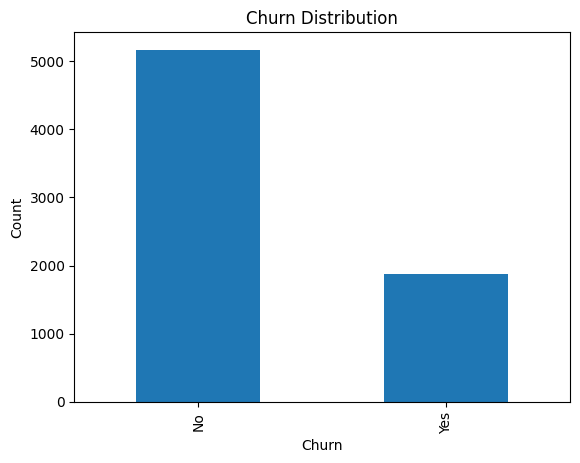

In [35]:
# Churn Distribution
df["Churn"].value_counts().plot(kind ="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

#### **Numeric columns vs Churn**


* Tenure
* MonthlyCharges
* TotalCharges

We have an additional numeric column SeniorCitizen, but it will not be considered in this check because we are going to convert it in a categorical column  with 'Yes' and 'No'.




In [36]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


<Figure size 600x400 with 0 Axes>

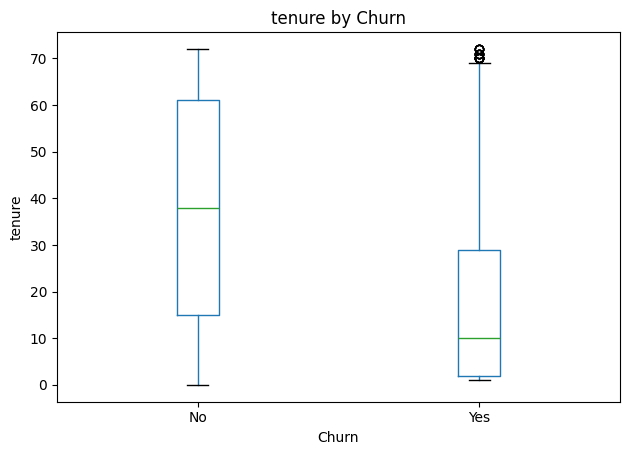

<Figure size 600x400 with 0 Axes>

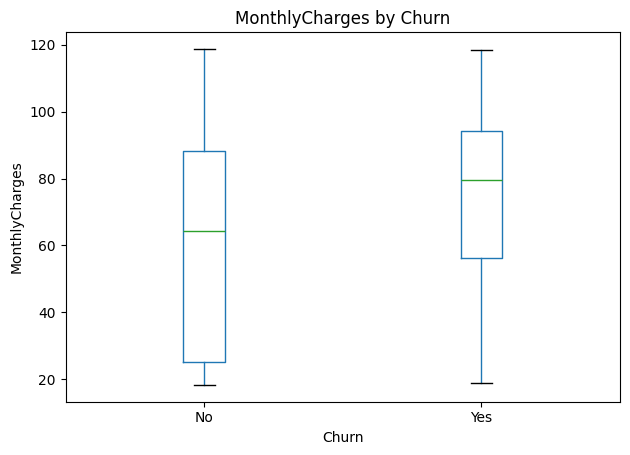

In [37]:
for col in ["tenure", "MonthlyCharges"]:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col, by="Churn", grid=False)
    plt.title(f"{col} by Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

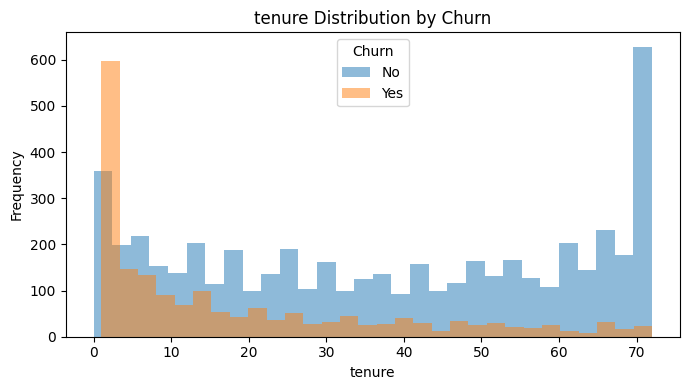

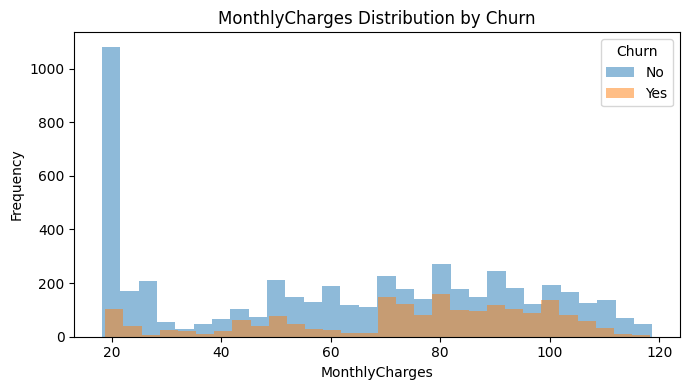

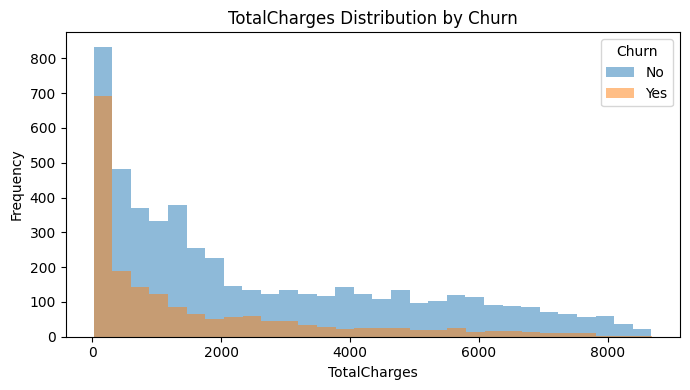

In [38]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for c in num_cols:
    plt.figure(figsize=(7,4))
    for label in ["No", "Yes"]:
        subset = df[df["Churn"] == label]
        plt.hist(subset[c], bins=30, alpha=0.5, label=label)
    plt.title(f"{c} Distribution by Churn")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()

### **Categorical Variables vs Churn**

In [39]:
categorical_check_cols = [
    "SeniorCitizen", "Contract", "PaymentMethod",
    "InternetService", "TechSupport", "OnlineSecurity", "PaperlessBilling"
] #Assumed to be the top drivers

In [40]:
for col in categorical_check_cols:
    print(f"\n--- {col} ---")
    churn_by_group = pd.crosstab(df[col], df["Churn"], normalize="index")
    display(churn_by_group.sort_values("Yes", ascending=False))


--- SeniorCitizen ---


Churn,No,Yes
SeniorCitizen,,
Yes,0.583187,0.416813
No,0.763938,0.236062



--- Contract ---


Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319



--- PaymentMethod ---


...

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
Yes,0.848337,0.151663
No internet service,0.925950,0.074050



--- OnlineSecurity ---


Churn,No,Yes
OnlineSecurity,,
No,0.582333,0.417667
Yes,0.853888,0.146112
No internet service,0.925950,0.074050



--- PaperlessBilling ---


Churn,No,Yes
PaperlessBilling,,
Yes,0.664349,0.335651
No,0.836699,0.163301


Prepare data for model building

In [41]:
df = df.drop(columns=["customerID"])

In [42]:
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

In [43]:
y.value_counts()

,count
Churn,
0,5174
1,1869


In [44]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 19)
X_test shape: (1409, 19)
y_train shape: (5634,)
y_test shape: (1409,)


In [47]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [48]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Train the first model

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

In [51]:
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

In [52]:
logreg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [53]:
y_pred = logreg_model.predict(X_test)
y_pred_proba = logreg_model.predict_proba(X_test)[:, 1]

In [54]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba), 4))

Accuracy: 0.8055
Precision: 0.6572
Recall: 0.5588
F1-score: 0.604
ROC-AUC: 0.8419


In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [56]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[926 109]
 [165 209]]


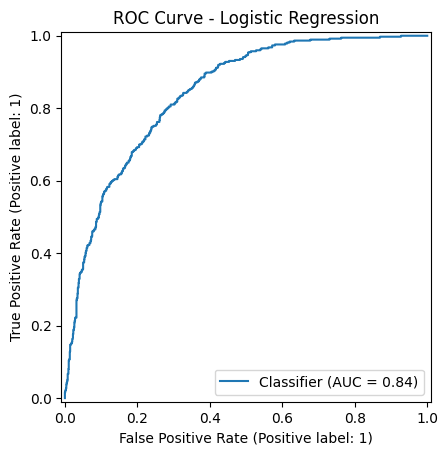

In [57]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [58]:
feature_names = logreg_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logreg_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)
coef_df.head(15)

,Feature,Coefficient
17,cat__InternetService_Fiber optic,0.643067
37,cat__Contract_Month-to-month,0.587326
2,num__TotalCharges,0.510281
36,cat__StreamingMovies_Yes,0.209985
33,cat__StreamingTV_Yes,0.209217
44,cat__PaymentMethod_Electronic check,0.204837
19,cat__OnlineSecurity_No,0.165232
28,cat__TechSupport_No,0.140760
15,cat__MultipleLines_Yes,0.111635
41,cat__PaperlessBilling_Yes,0.042211


In [59]:
coef_df.head(10)

,Feature,Coefficient
17,cat__InternetService_Fiber optic,0.643067
37,cat__Contract_Month-to-month,0.587326
2,num__TotalCharges,0.510281
36,cat__StreamingMovies_Yes,0.209985
33,cat__StreamingTV_Yes,0.209217
44,cat__PaymentMethod_Electronic check,0.204837
19,cat__OnlineSecurity_No,0.165232
28,cat__TechSupport_No,0.140760
15,cat__MultipleLines_Yes,0.111635
41,cat__PaperlessBilling_Yes,0.042211


In [60]:
coef_df.tail(10)

,Feature,Coefficient
20,cat__OnlineSecurity_No internet service,-0.290398
18,cat__InternetService_No,-0.290398
32,cat__StreamingTV_No internet service,-0.290398
26,cat__DeviceProtection_No internet service,-0.290398
23,cat__OnlineBackup_No internet service,-0.290398
40,cat__PaperlessBilling_No,-0.329752
1,num__MonthlyCharges,-0.585446
16,cat__InternetService_DSL,-0.640210
39,cat__Contract_Two year,-0.762730
0,num__tenure,-1.233867


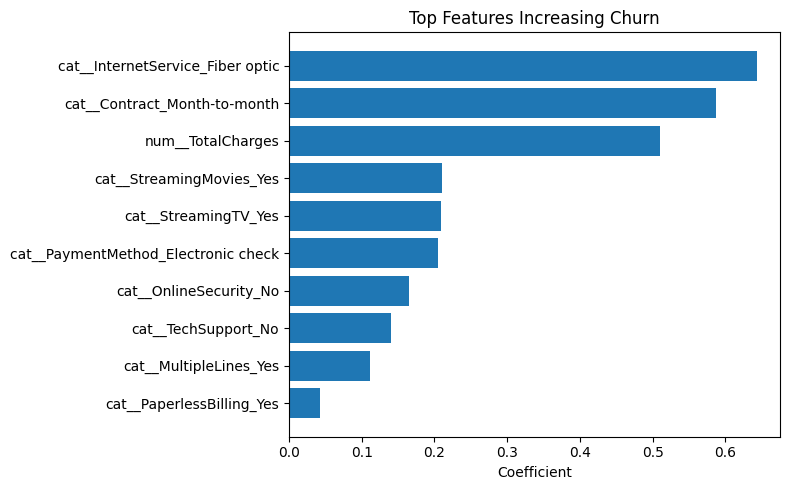

In [61]:
top_positive = coef_df.head(10).sort_values(by="Coefficient")
top_negative = coef_df.tail(10).sort_values(by="Coefficient")

plt.figure(figsize=(8,5))
plt.barh(top_positive["Feature"], top_positive["Coefficient"])
plt.title("Top Features Increasing Churn")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

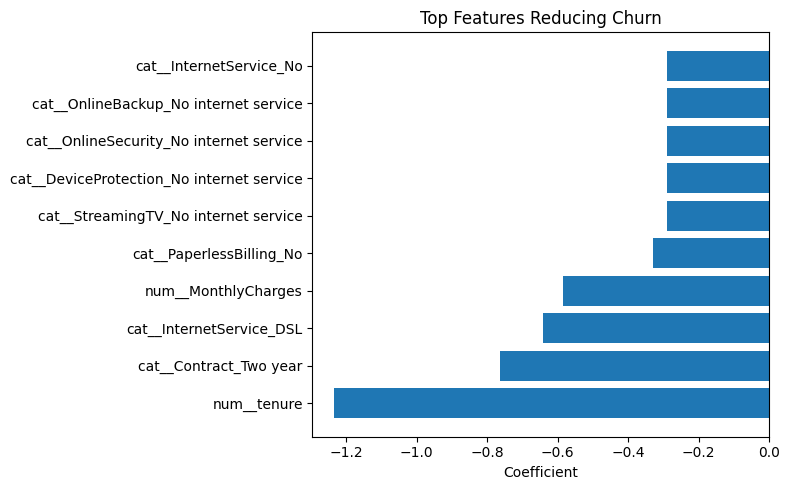

In [62]:
plt.figure(figsize=(8,5))
plt.barh(top_negative["Feature"], top_negative["Coefficient"])
plt.title("Top Features Reducing Churn")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

Multi-Model Comparison & SHAP Interpretation

In [63]:
!pip install shap -q

In [64]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import shap
import warnings
warnings.filterwarnings("ignore")

In [65]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=200, max_depth=10,
                                               random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(n_estimators=200,
                                                   learning_rate=0.05,
                                                   max_depth=4,
                                                   random_state=42))
    ]),
}

In [66]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_m  = model.predict(X_test)
    y_proba_m = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, y_pred_m),  4),
        "Precision": round(precision_score(y_test, y_pred_m), 4),
        "Recall":    round(recall_score(y_test, y_pred_m),    4),
        "F1-Score":  round(f1_score(y_test, y_pred_m),        4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_proba_m),  4),
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
display(results_df.reset_index(drop=True))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8419
1,Random Forest,0.8006,0.6598,0.5134,0.5774,0.8404
2,Gradient Boosting,0.7991,0.6512,0.5241,0.5807,0.8401
3,Decision Tree,0.7984,0.6347,0.5668,0.5989,0.8297


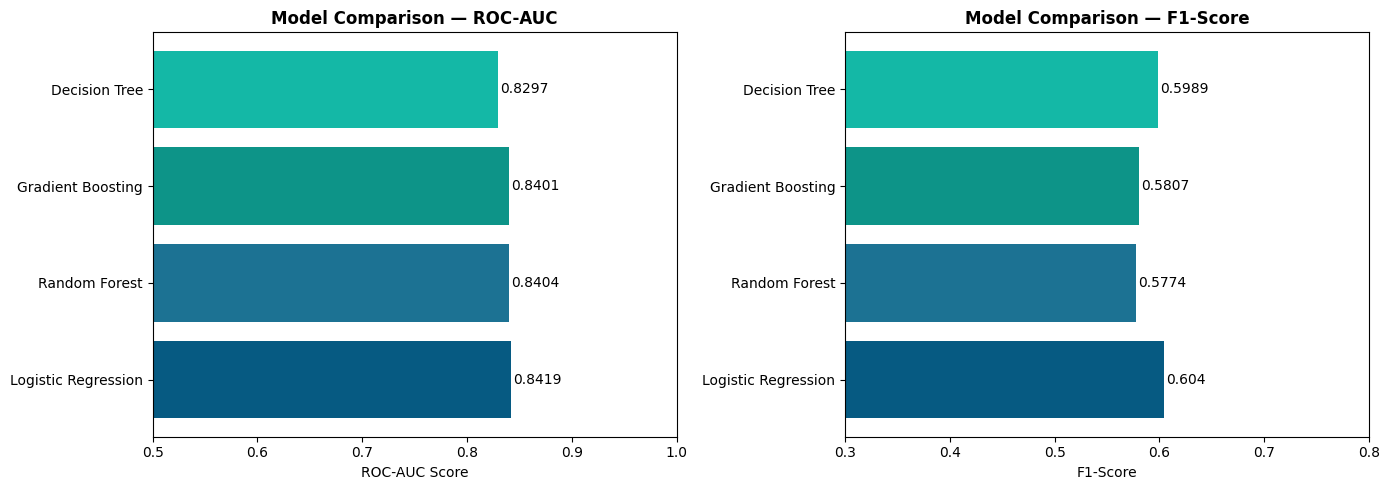

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#065A82", "#1C7293", "#0D9488", "#14B8A6"]

axes[0].barh(results_df["Model"], results_df["ROC-AUC"], color=colors)
axes[0].set_xlim(0.5, 1.0)
axes[0].set_xlabel("ROC-AUC Score")
axes[0].set_title("Model Comparison — ROC-AUC", fontweight="bold")
for i, v in enumerate(results_df["ROC-AUC"]):
    axes[0].text(v + 0.002, i, str(v), va="center", fontsize=10)

axes[1].barh(results_df["Model"], results_df["F1-Score"], color=colors)
axes[1].set_xlim(0.3, 0.8)
axes[1].set_xlabel("F1-Score")
axes[1].set_title("Model Comparison — F1-Score", fontweight="bold")
for i, v in enumerate(results_df["F1-Score"]):
    axes[1].text(v + 0.002, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.show()

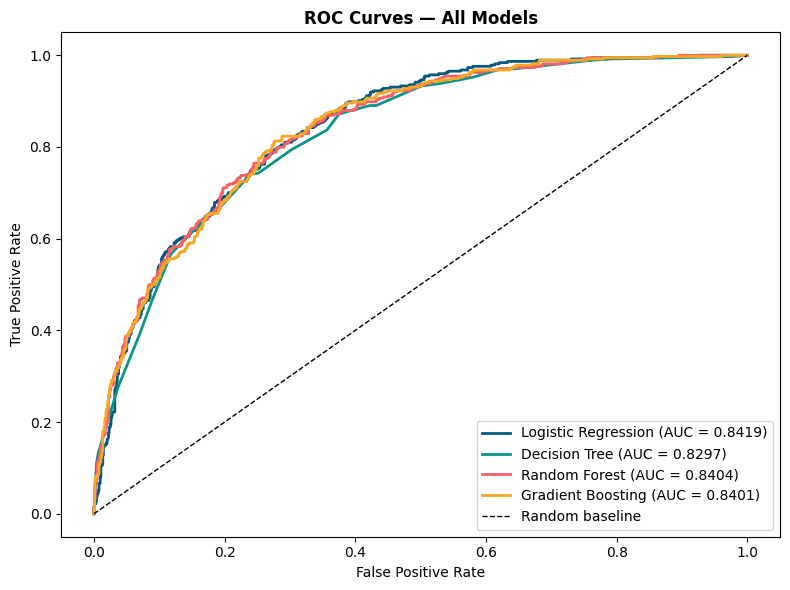

In [68]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
line_colors = ["#065A82", "#0D9488", "#F96167", "#F9A825"]

for (name, model), color in zip(models.items(), line_colors):
    y_proba_m = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba_m)
    auc = roc_auc_score(y_test, y_proba_m)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", color=color, lw=2)

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [69]:
best_model_name = results_df.iloc[0]["Model"]
best_model      = models[best_model_name]

print(f"✅ Best model: {best_model_name}")
print(f"   ROC-AUC : {results_df.iloc[0]['ROC-AUC']}")
print(f"   F1-Score: {results_df.iloc[0]['F1-Score']}")
print(f"   Recall  : {results_df.iloc[0]['Recall']}")

✅ Best model: Logistic Regression
   ROC-AUC : 0.8419
   F1-Score: 0.604
   Recall  : 0.5588


In [70]:
best_clf = best_model.named_steps["classifier"]
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)
feature_names_shap = best_model.named_steps["preprocessor"].get_feature_names_out()

if hasattr(best_clf, "feature_importances_"):
    explainer   = shap.TreeExplainer(best_clf)
    shap_values = explainer.shap_values(X_test_transformed)
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values
else:
    explainer = shap.LinearExplainer(best_clf, X_test_transformed)
    shap_vals = explainer.shap_values(X_test_transformed)

print("✅ SHAP explainer ready")

✅ SHAP explainer ready


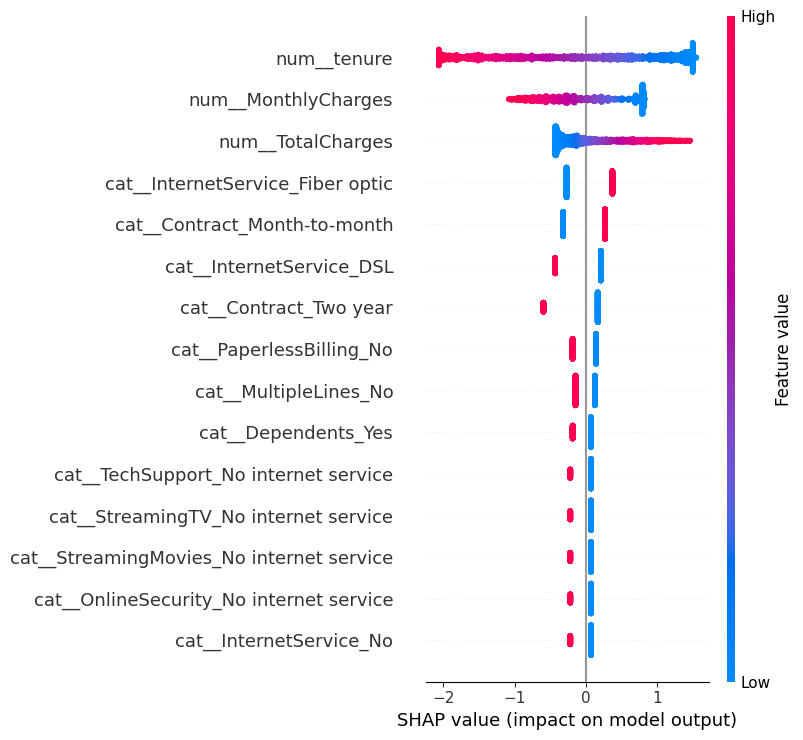

In [71]:
shap.summary_plot(
    shap_vals,
    X_test_transformed,
    feature_names=feature_names_shap,
    max_display=15,
    show=True
)

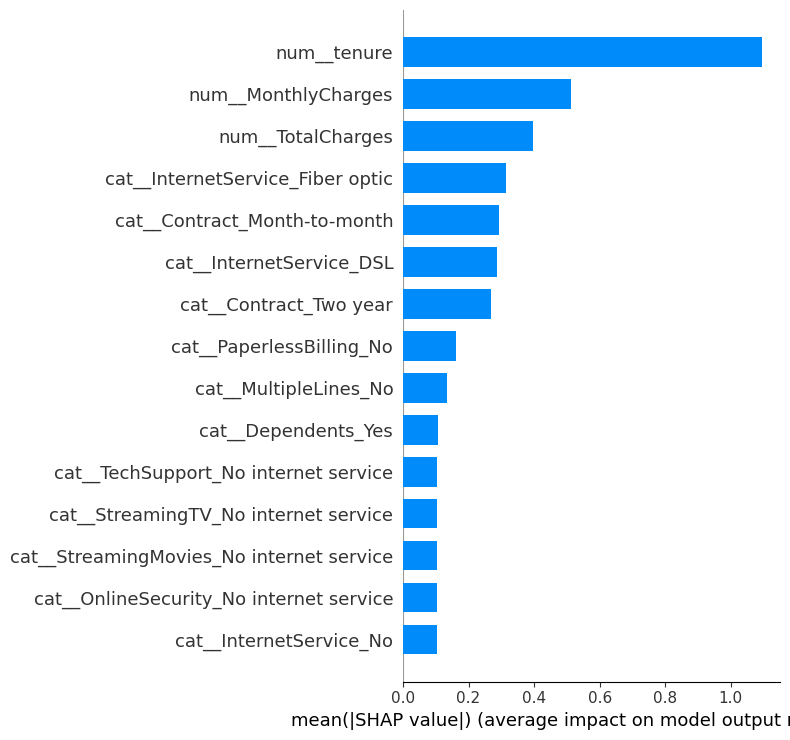

In [72]:
shap.summary_plot(
    shap_vals,
    X_test_transformed,
    feature_names=feature_names_shap,
    plot_type="bar",
    max_display=15,
    show=True
)

In [73]:
mean_shap = pd.DataFrame({
    "Feature":   feature_names_shap,
    "Mean_SHAP": shap_vals.mean(axis=0)
})

mean_shap["Direction"] = mean_shap["Mean_SHAP"].apply(
    lambda x: "⬆ Increases Churn" if x > 0 else "⬇ Reduces Churn"
)
mean_shap["Abs_SHAP"] = mean_shap["Mean_SHAP"].abs()
mean_shap = mean_shap.sort_values("Abs_SHAP", ascending=False).head(15)

display(mean_shap[["Feature", "Mean_SHAP", "Direction"]].reset_index(drop=True))

,Feature,Mean_SHAP,Direction
0,num__TotalCharges,0.057683,⬆ Increases Churn
1,num__MonthlyCharges,-0.057579,⬇ Reduces Churn
2,num__tenure,-0.051006,⬇ Reduces Churn
3,cat__Partner_No,0.019693,⬆ Increases Churn
4,cat__Partner_Yes,-0.017010,⬇ Reduces Churn
5,cat__Contract_Two year,-0.014085,⬇ Reduces Churn
6,cat__PaperlessBilling_No,0.011926,⬆ Increases Churn
7,cat__TechSupport_Yes,-0.011079,⬇ Reduces Churn
8,cat__InternetService_Fiber optic,0.009685,⬆ Increases Churn
9,cat__InternetService_DSL,-0.008647,⬇ Reduces Churn


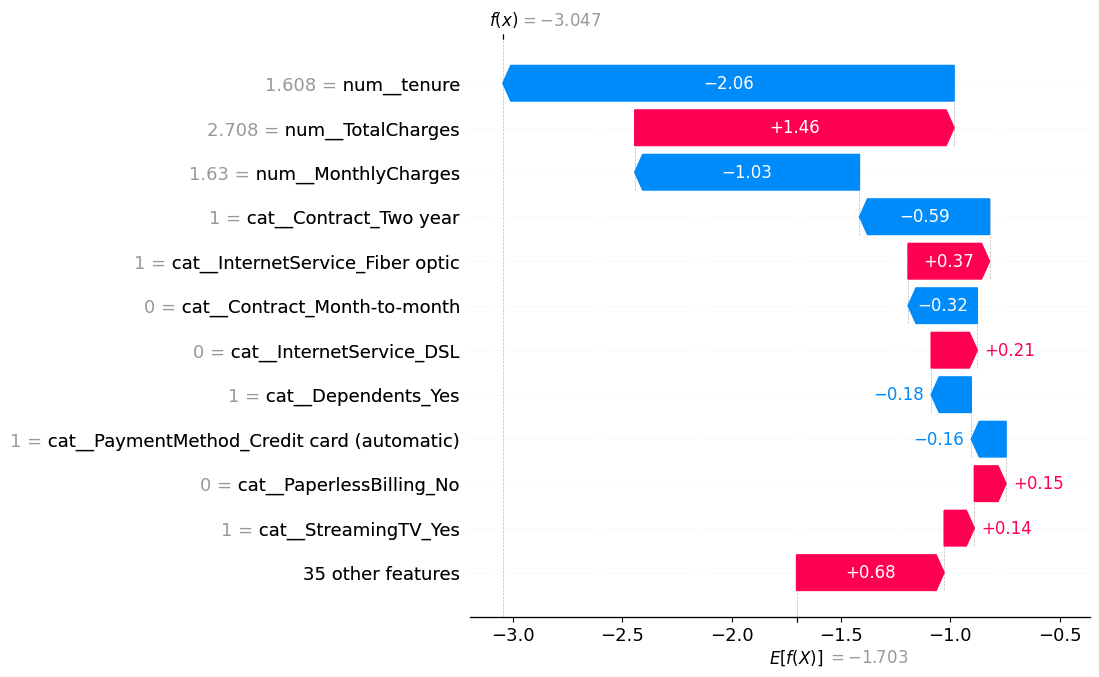


Customer #0 — Predicted churn probability: 0.045


In [74]:
sample_idx = 0  # módosítható bármely ügyfélre

shap_exp = shap.Explanation(
    values      = shap_vals[sample_idx],
    base_values = explainer.expected_value[1] if isinstance(explainer.expected_value, list)
                  else explainer.expected_value,
    data        = X_test_transformed[sample_idx],
    feature_names = list(feature_names_shap)
)

shap.waterfall_plot(shap_exp, max_display=12, show=True)

print(f"\nCustomer #{sample_idx} — Predicted churn probability:",
      round(best_model.predict_proba(X_test.iloc[[sample_idx]])[0][1], 3))